# Topic 19 — Confidence Intervals & Duality

Generates 10 publication-quality PNG figures for the `confidence-intervals-and-duality.mdx` topic
on [formalstatistics.com](https://www.formalstatistics.com).

**Figures produced:**
1. `19-ci-motivation.png` — 100 simulated 95% CIs + Bayesian contrast
2. `19-duality-diagram.png` — (T, θ₀)-plane, horizontal vs vertical slicing
3. `19-pivotal-construction.png` — z / t / χ² / F pivots
4. `19-wald-score-lrt-intervals.png` — Bernoulli CI trio
5. `19-wald-boundary-pathology.png` — Wald CI below 0 vs. Wilson staying in [0,1]
6. `19-binomial-coverage-curves.png` — BRO2001 coverage picture at n ∈ {20, 100, 500}
7. `19-clopper-pearson-construction.png` — beta-quantile derivation
8. `19-profile-likelihood.png` — Gamma shape-rate profile
9. `19-tost-preview.png` — TOST bioequivalence
10. `19-forward-map.png` — Topic 19's forward connections

All figures use the Topic 17–18 palette (amber Wald, purple Score, green LRT, grey reference)
plus blue `#2563EB` for pivots and red `#DC2626` for Wald-pathology warnings.
`np.random.seed(42)` for reproducibility. DPI 150, `bbox_inches='tight'`.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Imports + seed (reuse Topic 18's exactly)
# ═══════════════════════════════════════════════════════════════════════════════

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, t, chi2, f, beta as beta_dist, binom, gamma
from scipy.special import gammaln
from scipy.optimize import brentq
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

SEED = 42
np.random.seed(SEED)

OUTPUT_DIR = "public/images/topics/confidence-intervals-and-duality"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")
print(f"Seed: {SEED}")

Output directory: public/images/topics/confidence-intervals-and-duality
Seed: 42


In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Palette + matplotlib defaults (reuse Topic 18's, extended)
# ═══════════════════════════════════════════════════════════════════════════════

C = {
    'wald':  '#D97706',   # amber   — Wald statistic / CI
    'score': '#7C3AED',   # purple  — Score / Wilson
    'lrt':   '#10B981',   # green   — LRT
    'ref':   '#475569',   # grey    — reference / theoretical
    'pivot': '#2563EB',   # blue    — pivot (Topic 19 addition)
    'warn':  '#DC2626',   # red     — Wald-pathology warnings (Topic 19 addition)
}

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.15,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
})

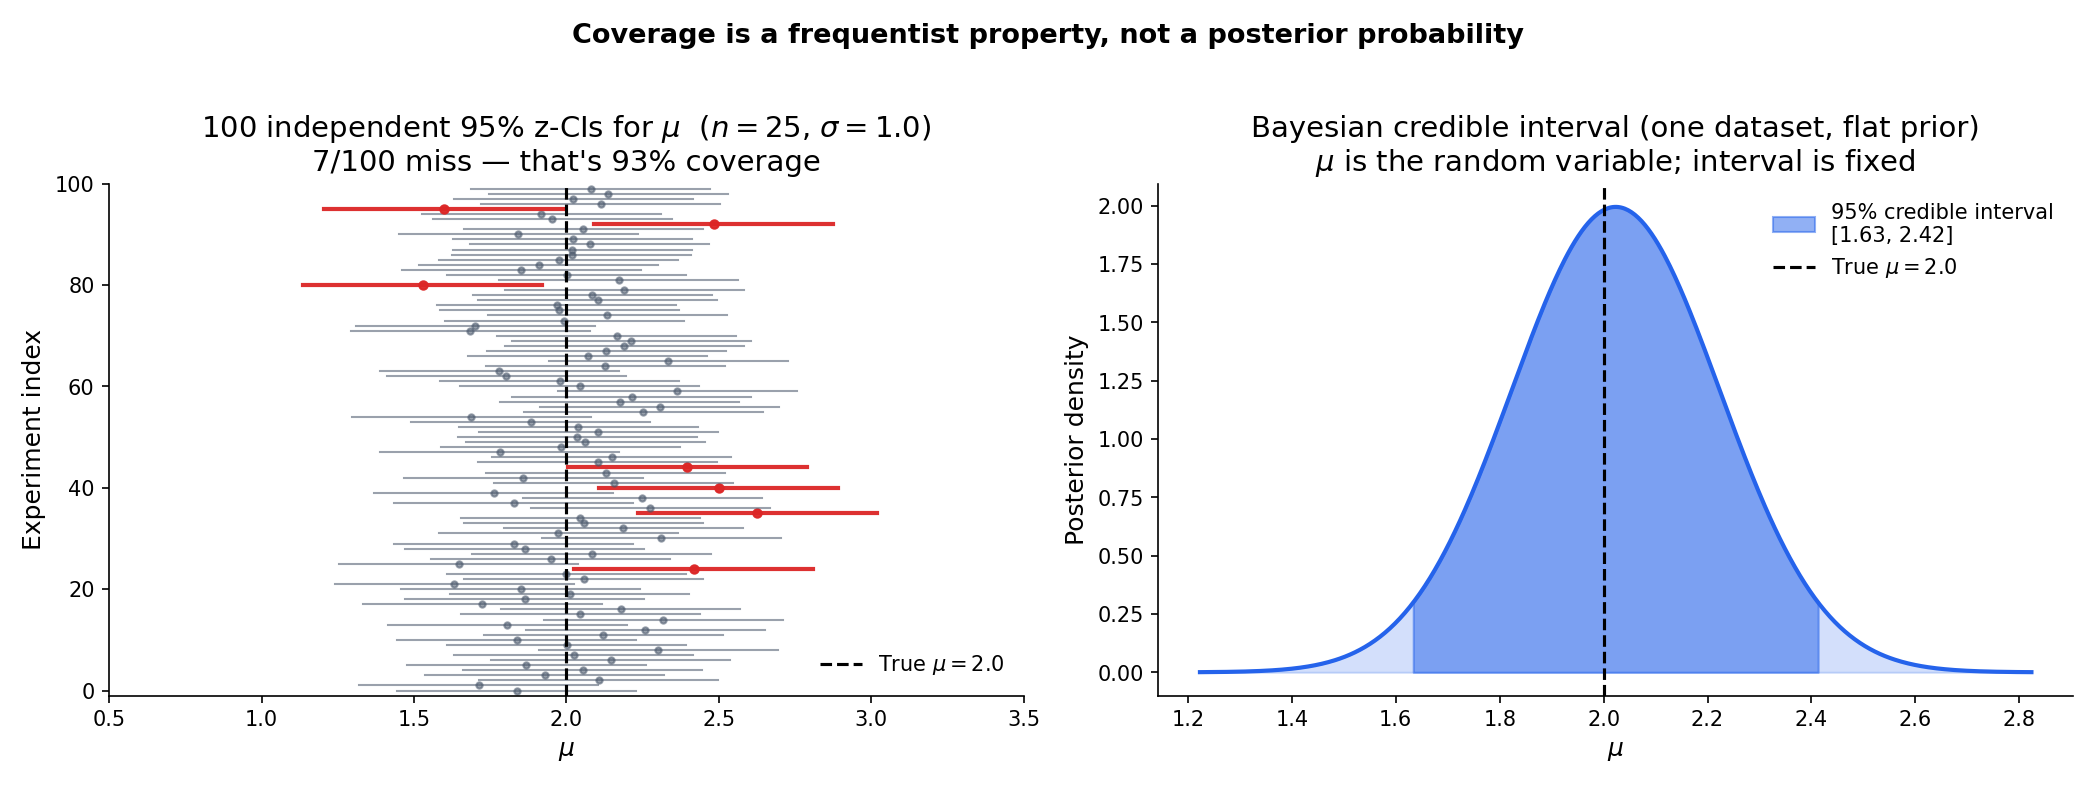

Saved: 19-ci-motivation.png  (7/100 intervals missed μ = 2.0)


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Figure 1: CI motivation (§19.1)
# Frequentist coverage vs. Bayesian posterior
# ═══════════════════════════════════════════════════════════════════════════════

np.random.seed(SEED)

mu_true = 2.0
sigma = 1.0
n = 25
n_experiments = 100
z95 = norm.ppf(0.975)

samples = np.random.normal(mu_true, sigma, size=(n_experiments, n))
xbars = samples.mean(axis=1)
half_width = z95 * sigma / np.sqrt(n)
lowers = xbars - half_width
uppers = xbars + half_width
covers = (lowers <= mu_true) & (uppers >= mu_true)
n_miss = int((~covers).sum())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: 100 CIs, red = miss
for i in range(n_experiments):
    if covers[i]:
        ax1.plot([lowers[i], uppers[i]], [i, i], color=C['ref'], lw=1.0, alpha=0.55)
        ax1.plot(xbars[i], i, 'o', ms=3, color=C['ref'], alpha=0.55)
    else:
        ax1.plot([lowers[i], uppers[i]], [i, i], color=C['warn'], lw=2.0, alpha=0.95)
        ax1.plot(xbars[i], i, 'o', ms=4, color=C['warn'], alpha=0.95)

ax1.axvline(mu_true, color='k', lw=1.5, ls='--', label=fr'True $\mu = {mu_true}$')
ax1.set_xlim(0.5, 3.5)
ax1.set_ylim(-1, n_experiments)
ax1.set_xlabel(r'$\mu$')
ax1.set_ylabel('Experiment index')
ax1.set_title(f'100 independent 95% z-CIs for $\\mu$  ($n={n}$, $\\sigma={sigma}$)\n'
              f'{n_miss}/100 miss — that\'s {100 - n_miss}% coverage')
ax1.legend(loc='lower right', frameon=False)

# Right panel: Bayesian posterior for one dataset (flat prior)
chosen_idx = 7
xbar_one = xbars[chosen_idx]
posterior_sd = sigma / np.sqrt(n)
mu_grid = np.linspace(xbar_one - 4 * posterior_sd, xbar_one + 4 * posterior_sd, 500)
posterior = norm.pdf(mu_grid, loc=xbar_one, scale=posterior_sd)

ax2.fill_between(mu_grid, posterior, alpha=0.20, color=C['pivot'])
ax2.plot(mu_grid, posterior, color=C['pivot'], lw=2)

cred_lower = xbar_one - 1.96 * posterior_sd
cred_upper = xbar_one + 1.96 * posterior_sd
mask = (mu_grid >= cred_lower) & (mu_grid <= cred_upper)
ax2.fill_between(mu_grid[mask], posterior[mask], alpha=0.5, color=C['pivot'],
                 label=f'95% credible interval\n[{cred_lower:.2f}, {cred_upper:.2f}]')
ax2.axvline(mu_true, color='k', lw=1.5, ls='--', label=fr'True $\mu = {mu_true}$')

ax2.set_xlabel(r'$\mu$')
ax2.set_ylabel('Posterior density')
ax2.set_title('Bayesian credible interval (one dataset, flat prior)\n'
              r'$\mu$ is the random variable; interval is fixed')
ax2.legend(loc='upper right', frameon=False)

fig.suptitle("Coverage is a frequentist property, not a posterior probability",
             fontsize=13, y=1.02, weight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '19-ci-motivation.png'))
plt.show()
print(f"Saved: 19-ci-motivation.png  ({n_miss}/100 intervals missed μ = {mu_true})")

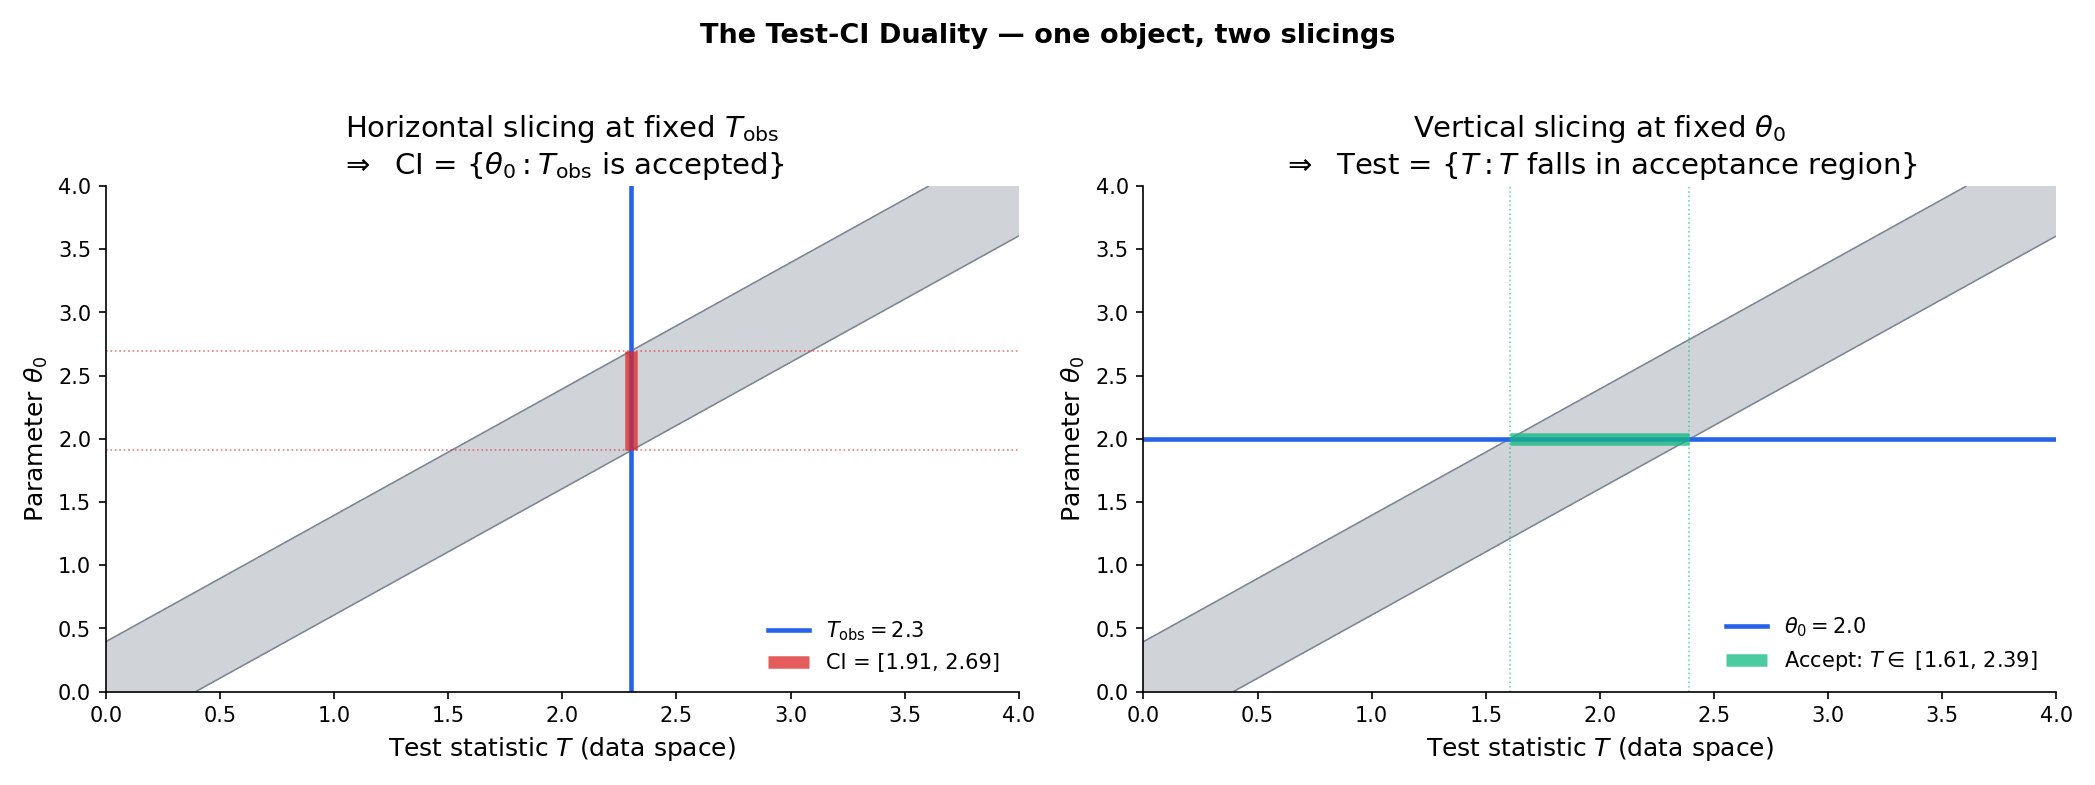

Saved: 19-duality-diagram.png


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Figure 2: Duality diagram (§19.2)
# (T, θ₀)-plane with horizontal and vertical slicings
# ═══════════════════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sigma = 1.0
n = 25
z95 = norm.ppf(0.975)
se = sigma / np.sqrt(n)

theta_grid = np.linspace(0, 4, 300)
T_grid = np.linspace(0, 4, 300)
TT, TH = np.meshgrid(T_grid, theta_grid)
accept = (np.abs(TT - TH) < z95 * se).astype(float)

T_obs = 2.3
theta_0_fixed = 2.0

# Left: horizontal slicing (CI view)
ax1.contourf(TT, TH, accept, levels=[0.5, 1.5], colors=[C['ref']], alpha=0.25)
ax1.contour(TT, TH, accept, levels=[0.5], colors=[C['ref']], linewidths=0.8, alpha=0.6)
ax1.axvline(T_obs, color=C['pivot'], lw=2.2, label=fr'$T_{{\rm obs}} = {T_obs}$')
ci_lower = T_obs - z95 * se
ci_upper = T_obs + z95 * se
ax1.plot([T_obs, T_obs], [ci_lower, ci_upper], color=C['warn'], lw=6, alpha=0.75, solid_capstyle='butt',
         label=f'CI = [{ci_lower:.2f}, {ci_upper:.2f}]')
ax1.axhline(ci_lower, color=C['warn'], lw=0.8, ls=':', alpha=0.6)
ax1.axhline(ci_upper, color=C['warn'], lw=0.8, ls=':', alpha=0.6)

ax1.set_xlabel(r'Test statistic $T$ (data space)')
ax1.set_ylabel(r'Parameter $\theta_0$')
ax1.set_title("Horizontal slicing at fixed $T_{\\rm obs}$\n"
              r'$\Rightarrow$  CI = $\{\theta_0 : T_{\rm obs}$ is accepted$\}$')
ax1.legend(loc='lower right', frameon=False)
ax1.set_xlim(0, 4)
ax1.set_ylim(0, 4)

# Right: vertical slicing (test view)
ax2.contourf(TT, TH, accept, levels=[0.5, 1.5], colors=[C['ref']], alpha=0.25)
ax2.contour(TT, TH, accept, levels=[0.5], colors=[C['ref']], linewidths=0.8, alpha=0.6)
ax2.axhline(theta_0_fixed, color=C['pivot'], lw=2.2, label=fr'$\theta_0 = {theta_0_fixed}$')
accept_lower = theta_0_fixed - z95 * se
accept_upper = theta_0_fixed + z95 * se
ax2.plot([accept_lower, accept_upper], [theta_0_fixed, theta_0_fixed], color=C['lrt'],
         lw=6, alpha=0.75, solid_capstyle='butt',
         label=f'Accept: $T \\in$ [{accept_lower:.2f}, {accept_upper:.2f}]')
ax2.axvline(accept_lower, color=C['lrt'], lw=0.8, ls=':', alpha=0.6)
ax2.axvline(accept_upper, color=C['lrt'], lw=0.8, ls=':', alpha=0.6)

ax2.set_xlabel(r'Test statistic $T$ (data space)')
ax2.set_ylabel(r'Parameter $\theta_0$')
ax2.set_title(r'Vertical slicing at fixed $\theta_0$'
              '\n$\\Rightarrow$  Test = $\\{T : T$ falls in acceptance region$\\}$')
ax2.legend(loc='lower right', frameon=False)
ax2.set_xlim(0, 4)
ax2.set_ylim(0, 4)

fig.suptitle("The Test-CI Duality — one object, two slicings",
             fontsize=13, y=1.02, weight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '19-duality-diagram.png'))
plt.show()
print("Saved: 19-duality-diagram.png")

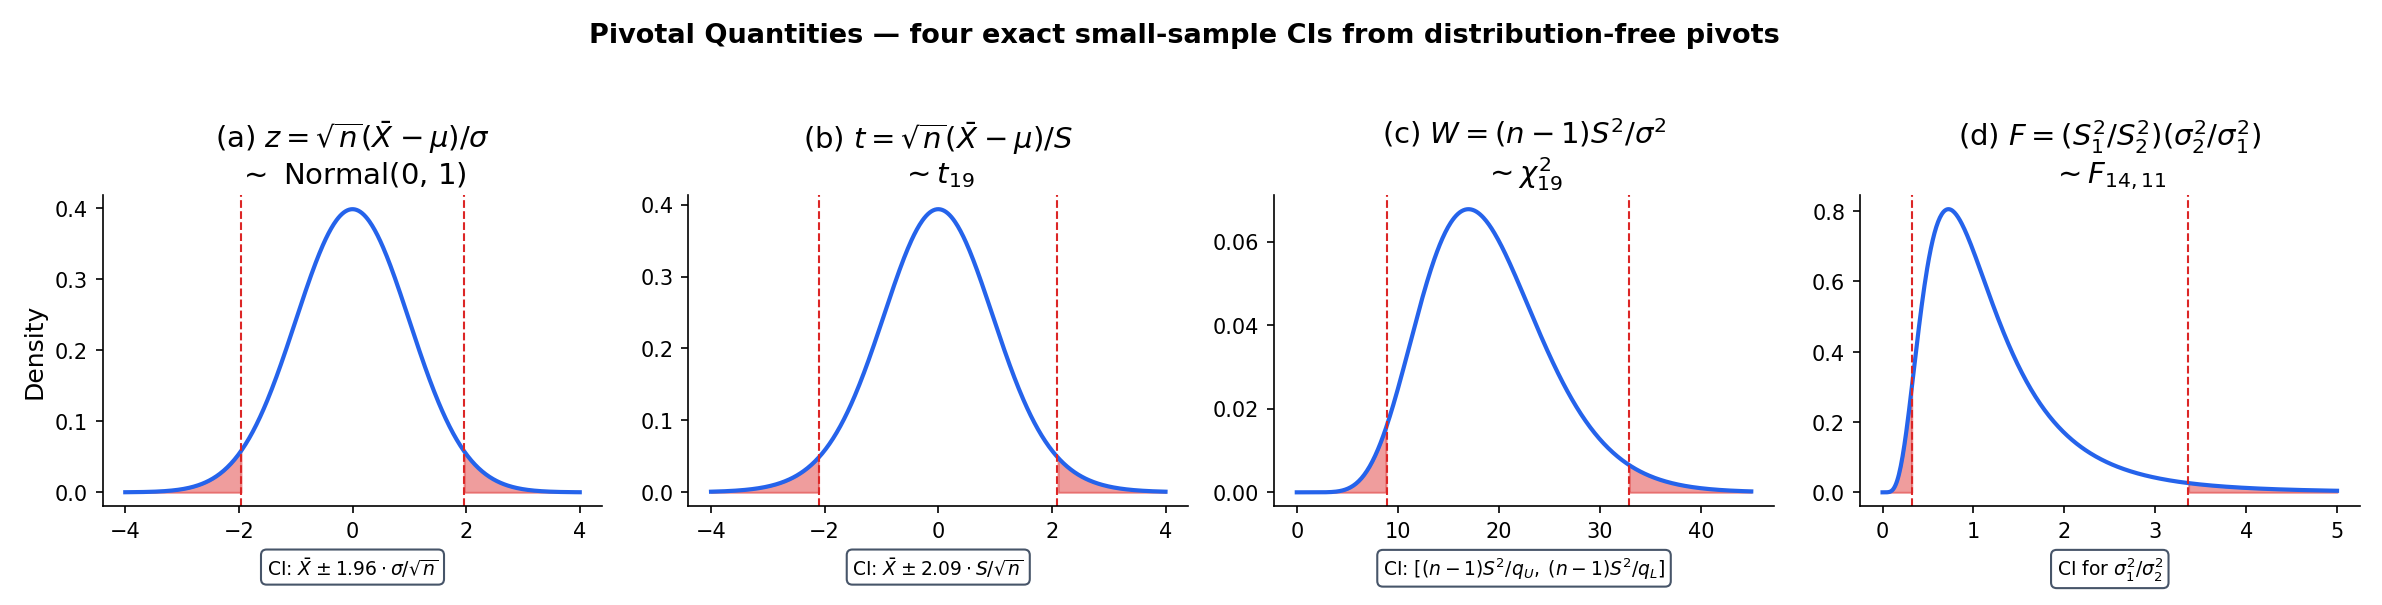

Saved: 19-pivotal-construction.png


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Figure 3: Pivotal quantities (§19.3)
# z, t, χ², F pivots — the four exact small-sample CIs
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
n = 20
alpha = 0.05

# (a) z-pivot
ax = axes[0]
x = np.linspace(-4, 4, 500)
ax.plot(x, norm.pdf(x), color=C['pivot'], lw=2)
zq = norm.ppf(1 - alpha / 2)
ax.fill_between(x[x <= -zq], norm.pdf(x[x <= -zq]), alpha=0.45, color=C['warn'])
ax.fill_between(x[x >= zq], norm.pdf(x[x >= zq]), alpha=0.45, color=C['warn'])
ax.axvline(-zq, color=C['warn'], lw=1, ls='--')
ax.axvline(zq, color=C['warn'], lw=1, ls='--')
ax.set_title(r'(a) $z = \sqrt{n}(\bar X - \mu)/\sigma$'
             '\n' r'$\sim$ Normal(0, 1)')
ax.set_xlabel(r'$z$')
ax.set_ylabel('Density')
ax.text(0.5, -0.22, fr'CI: $\bar X \pm {zq:.2f} \cdot \sigma/\sqrt{{n}}$',
        transform=ax.transAxes, ha='center', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=C['ref']))

# (b) t-pivot
ax = axes[1]
df = n - 1
x = np.linspace(-4, 4, 500)
ax.plot(x, t.pdf(x, df), color=C['pivot'], lw=2)
tq = t.ppf(1 - alpha / 2, df)
ax.fill_between(x[x <= -tq], t.pdf(x[x <= -tq], df), alpha=0.45, color=C['warn'])
ax.fill_between(x[x >= tq], t.pdf(x[x >= tq], df), alpha=0.45, color=C['warn'])
ax.axvline(-tq, color=C['warn'], lw=1, ls='--')
ax.axvline(tq, color=C['warn'], lw=1, ls='--')
ax.set_title(rf'(b) $t = \sqrt{{n}}(\bar X - \mu)/S$'
             '\n' rf'$\sim t_{{{df}}}$')
ax.set_xlabel(r'$t$')
ax.text(0.5, -0.22, fr'CI: $\bar X \pm {tq:.2f} \cdot S/\sqrt{{n}}$',
        transform=ax.transAxes, ha='center', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=C['ref']))

# (c) χ²-pivot
ax = axes[2]
df = n - 1
x = np.linspace(0, 45, 500)
ax.plot(x, chi2.pdf(x, df), color=C['pivot'], lw=2)
chi_lower = chi2.ppf(alpha / 2, df)
chi_upper = chi2.ppf(1 - alpha / 2, df)
ax.fill_between(x[x <= chi_lower], chi2.pdf(x[x <= chi_lower], df), alpha=0.45, color=C['warn'])
ax.fill_between(x[x >= chi_upper], chi2.pdf(x[x >= chi_upper], df), alpha=0.45, color=C['warn'])
ax.axvline(chi_lower, color=C['warn'], lw=1, ls='--')
ax.axvline(chi_upper, color=C['warn'], lw=1, ls='--')
ax.set_title(rf'(c) $W = (n-1)S^2/\sigma^2$'
             '\n' rf'$\sim \chi^2_{{{df}}}$')
ax.set_xlabel(r'$W$')
ax.text(0.5, -0.22, r'CI: $[(n-1)S^2/q_U, \; (n-1)S^2/q_L]$',
        transform=ax.transAxes, ha='center', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=C['ref']))

# (d) F-pivot
ax = axes[3]
n1, n2 = 15, 12
df1, df2 = n1 - 1, n2 - 1
x = np.linspace(0, 5, 500)
ax.plot(x, f.pdf(x, df1, df2), color=C['pivot'], lw=2)
f_lower = f.ppf(alpha / 2, df1, df2)
f_upper = f.ppf(1 - alpha / 2, df1, df2)
ax.fill_between(x[x <= f_lower], f.pdf(x[x <= f_lower], df1, df2), alpha=0.45, color=C['warn'])
ax.fill_between(x[x >= f_upper], f.pdf(x[x >= f_upper], df1, df2), alpha=0.45, color=C['warn'])
ax.axvline(f_lower, color=C['warn'], lw=1, ls='--')
ax.axvline(f_upper, color=C['warn'], lw=1, ls='--')
ax.set_title(rf'(d) $F = (S_1^2/S_2^2)(\sigma_2^2/\sigma_1^2)$'
             '\n' rf'$\sim F_{{{df1},{df2}}}$')
ax.set_xlabel(r'$F$')
ax.text(0.5, -0.22, r'CI for $\sigma_1^2/\sigma_2^2$',
        transform=ax.transAxes, ha='center', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=C['ref']))

fig.suptitle("Pivotal Quantities — four exact small-sample CIs from distribution-free pivots",
             fontsize=13, y=1.03, weight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(os.path.join(OUTPUT_DIR, '19-pivotal-construction.png'))
plt.show()
print("Saved: 19-pivotal-construction.png")

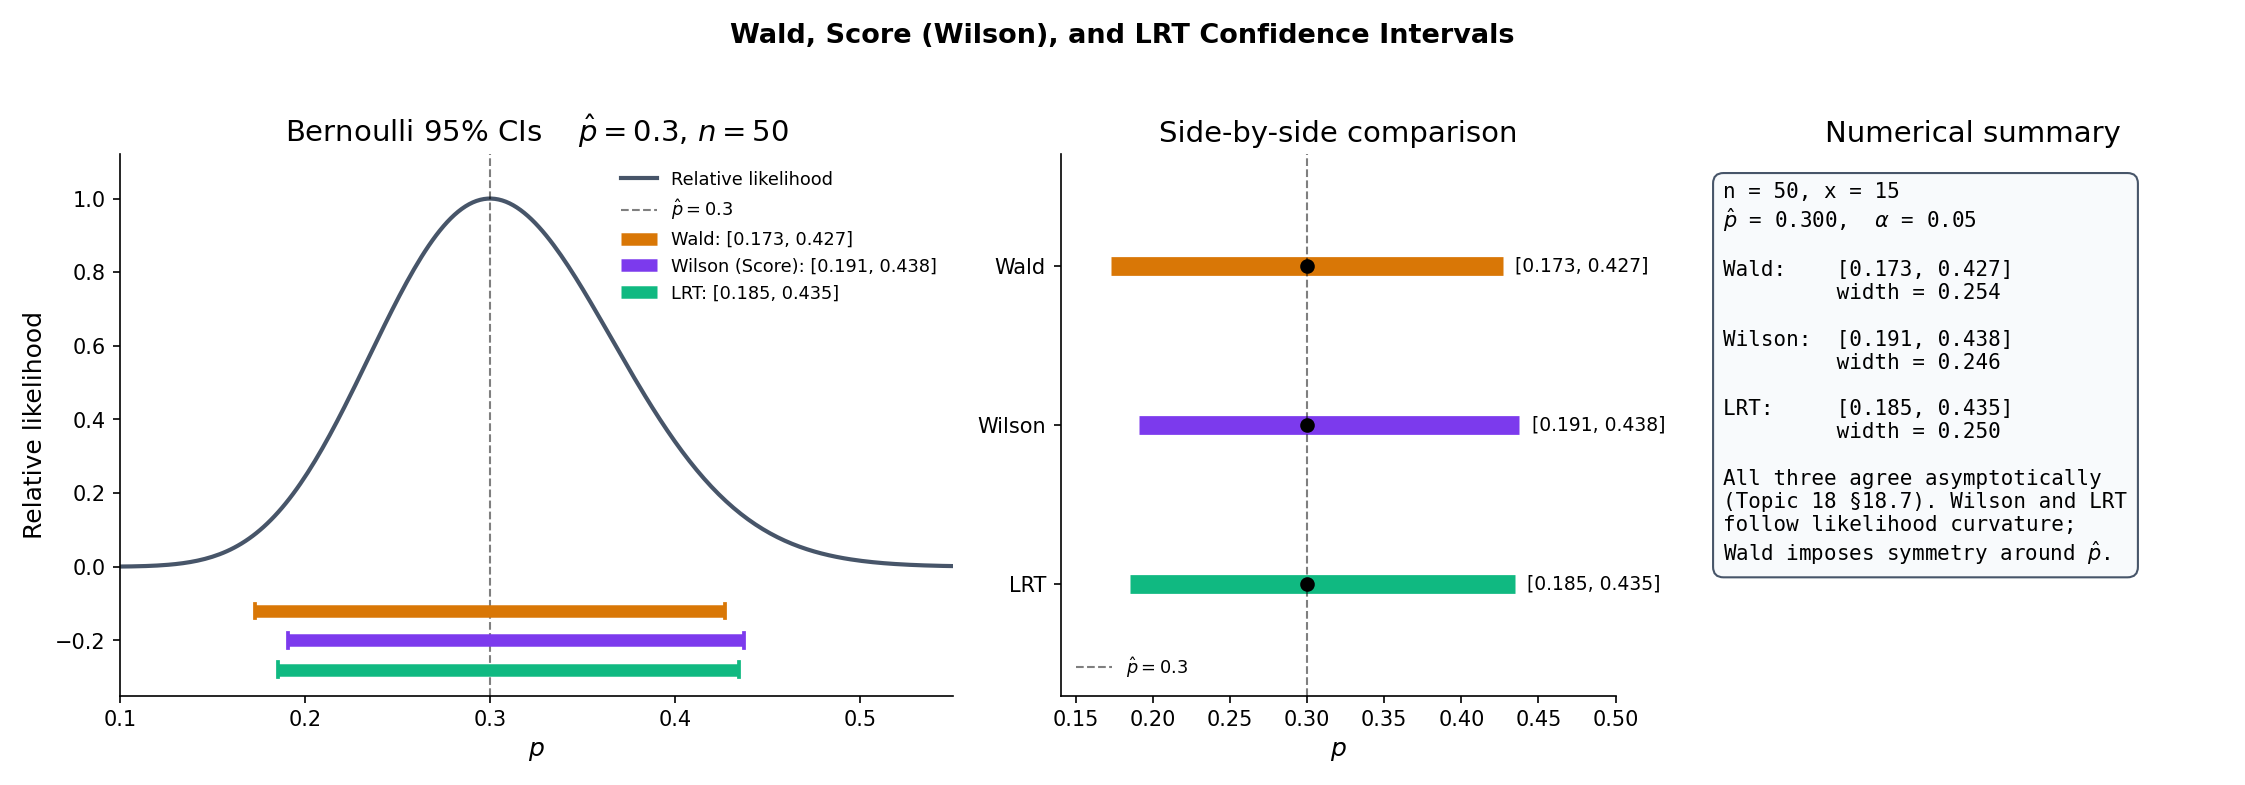

Saved: 19-wald-score-lrt-intervals.png
  Wald:   [0.1730, 0.4270]  width = 0.2540
  Wilson: [0.1910, 0.4375]  width = 0.2465
  LRT:    [0.1852, 0.4348]  width = 0.2496


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Figure 4: Wald / Score / LRT CIs (§19.4)
# Bernoulli p̂ = 0.3, n = 50
# ═══════════════════════════════════════════════════════════════════════════════

n = 50
x_obs = 15
p_hat = x_obs / n
alpha = 0.05
z95 = norm.ppf(1 - alpha / 2)
chi2_crit_1 = chi2.ppf(1 - alpha, 1)

# Wald
se_wald = np.sqrt(p_hat * (1 - p_hat) / n)
wald_lower = p_hat - z95 * se_wald
wald_upper = p_hat + z95 * se_wald

# Wilson (Score-test-inverted; Proof 2 of §19.5)
denom = 1 + z95**2 / n
wilson_center = (p_hat + z95**2 / (2 * n)) / denom
wilson_half = (z95 / np.sqrt(n)) * np.sqrt(p_hat * (1 - p_hat) + z95**2 / (4 * n)) / denom
wilson_lower = wilson_center - wilson_half
wilson_upper = wilson_center + wilson_half

# LRT CI: find p such that -2 log Λ_n(p) <= χ²_{1, 1-α}
def neg2_lambda(p):
    if p <= 0 or p >= 1:
        return np.inf
    return -2 * (x_obs * np.log(p / p_hat) + (n - x_obs) * np.log((1 - p) / (1 - p_hat)))

lrt_lower = brentq(lambda p: neg2_lambda(p) - chi2_crit_1, 1e-6, p_hat - 1e-6)
lrt_upper = brentq(lambda p: neg2_lambda(p) - chi2_crit_1, p_hat + 1e-6, 1 - 1e-6)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5),
                                     gridspec_kw={'width_ratios': [1.5, 1, 0.9]})

# Left: likelihood curve with three CI bars underneath
p_grid = np.linspace(0.005, 0.995, 500)
loglik = x_obs * np.log(p_grid) + (n - x_obs) * np.log(1 - p_grid)
rel_lik = np.exp(loglik - loglik.max())

ax1.plot(p_grid, rel_lik, color=C['ref'], lw=2, label='Relative likelihood')
ax1.axvline(p_hat, color='k', lw=1, ls='--', alpha=0.5, label=fr'$\hat p = {p_hat}$')

y_levels = [-0.12, -0.20, -0.28]
for y, (lo, up, name, col) in zip(y_levels, [
    (wald_lower, wald_upper, 'Wald', C['wald']),
    (wilson_lower, wilson_upper, 'Wilson (Score)', C['score']),
    (lrt_lower, lrt_upper, 'LRT', C['lrt']),
]):
    ax1.plot([lo, up], [y, y], color=col, lw=6, solid_capstyle='butt',
             label=f'{name}: [{lo:.3f}, {up:.3f}]')
    ax1.plot([lo, lo], [y - 0.02, y + 0.02], color=col, lw=1.8)
    ax1.plot([up, up], [y - 0.02, y + 0.02], color=col, lw=1.8)

ax1.set_xlabel(r'$p$')
ax1.set_ylabel('Relative likelihood')
ax1.set_title(f'Bernoulli 95% CIs    $\\hat p = {p_hat}$, $n = {n}$')
ax1.set_ylim(-0.35, 1.12)
ax1.set_xlim(0.10, 0.55)
ax1.legend(loc='upper right', frameon=False, fontsize=8.5)

# Center: side-by-side bars
methods = ['Wald', 'Wilson', 'LRT']
pairs = [(wald_lower, wald_upper), (wilson_lower, wilson_upper), (lrt_lower, lrt_upper)]
colors = [C['wald'], C['score'], C['lrt']]

for yp, (lo, up), col, name in zip([0, 1, 2], pairs, colors, methods):
    ax2.plot([lo, up], [yp, yp], color=col, lw=9, solid_capstyle='butt')
    ax2.plot(p_hat, yp, 'ok', ms=6)
    ax2.text(up + 0.008, yp, f'[{lo:.3f}, {up:.3f}]', va='center', fontsize=9)

ax2.axvline(p_hat, color='k', lw=1, ls='--', alpha=0.5, label=fr'$\hat p = {p_hat}$')
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(methods)
ax2.set_xlabel(r'$p$')
ax2.set_xlim(0.14, 0.50)
ax2.set_ylim(-0.7, 2.7)
ax2.invert_yaxis()
ax2.set_title('Side-by-side comparison')
ax2.legend(loc='lower left', frameon=False, fontsize=8.5)

# Right: numerical readout
ax3.axis('off')
readout = (
    f'n = {n}, x = {x_obs}\n'
    f'$\\hat p$ = {p_hat:.3f},  $\\alpha$ = {alpha}\n\n'
    f'Wald:    [{wald_lower:.3f}, {wald_upper:.3f}]\n'
    f'         width = {wald_upper - wald_lower:.3f}\n\n'
    f'Wilson:  [{wilson_lower:.3f}, {wilson_upper:.3f}]\n'
    f'         width = {wilson_upper - wilson_lower:.3f}\n\n'
    f'LRT:     [{lrt_lower:.3f}, {lrt_upper:.3f}]\n'
    f'         width = {lrt_upper - lrt_lower:.3f}\n\n'
    'All three agree asymptotically\n'
    '(Topic 18 §18.7). Wilson and LRT\n'
    'follow likelihood curvature;\n'
    r'Wald imposes symmetry around $\hat p$.'
)
ax3.text(0.0, 0.95, readout, transform=ax3.transAxes, fontsize=10,
         verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8fafc', edgecolor=C['ref']))
ax3.set_title('Numerical summary')

fig.suptitle("Wald, Score (Wilson), and LRT Confidence Intervals",
             fontsize=13, y=1.02, weight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '19-wald-score-lrt-intervals.png'))
plt.show()
print(f"Saved: 19-wald-score-lrt-intervals.png")
print(f"  Wald:   [{wald_lower:.4f}, {wald_upper:.4f}]  width = {wald_upper - wald_lower:.4f}")
print(f"  Wilson: [{wilson_lower:.4f}, {wilson_upper:.4f}]  width = {wilson_upper - wilson_lower:.4f}")
print(f"  LRT:    [{lrt_lower:.4f}, {lrt_upper:.4f}]  width = {lrt_upper - lrt_lower:.4f}")

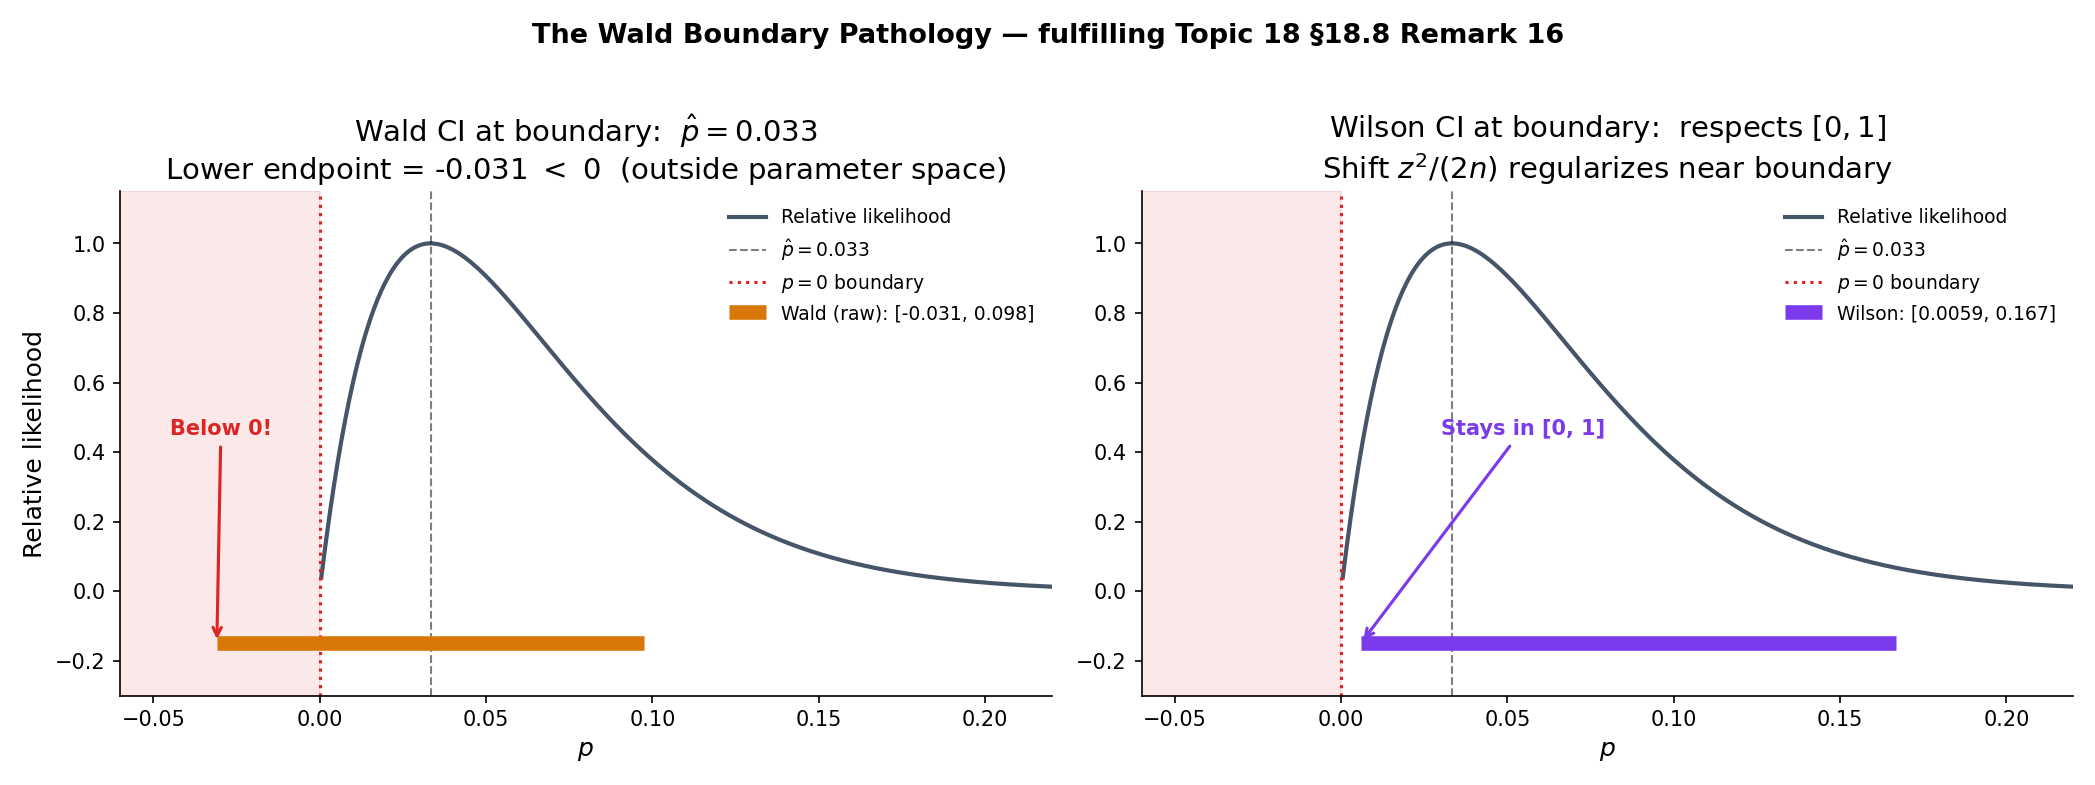

Saved: 19-wald-boundary-pathology.png
  Wald raw:  [-0.0309, 0.0976]   <- lower bound below 0
  Wilson:    [0.0059, 0.1667]


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Figure 5: Wald boundary pathology (§19.5)
# Small p̂ near 0: Wald breaks, Wilson doesn't
# ═══════════════════════════════════════════════════════════════════════════════

n = 30
x_obs = 1
p_hat = x_obs / n
alpha = 0.05
z95 = norm.ppf(1 - alpha / 2)

# Wald (raw, including negative lower endpoint)
se_wald = np.sqrt(p_hat * (1 - p_hat) / n)
wald_lower = p_hat - z95 * se_wald
wald_upper = p_hat + z95 * se_wald

# Wilson
denom = 1 + z95**2 / n
wilson_center = (p_hat + z95**2 / (2 * n)) / denom
wilson_half = (z95 / np.sqrt(n)) * np.sqrt(p_hat * (1 - p_hat) + z95**2 / (4 * n)) / denom
wilson_lower = max(0, wilson_center - wilson_half)
wilson_upper = min(1, wilson_center + wilson_half)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Shared: likelihood curve near 0
p_grid = np.linspace(-0.05, 0.25, 500)
valid = (p_grid > 0) & (p_grid < 1)
loglik = np.full_like(p_grid, np.nan)
loglik[valid] = x_obs * np.log(p_grid[valid]) + (n - x_obs) * np.log(1 - p_grid[valid])
rel_lik = np.exp(loglik - np.nanmax(loglik))

# Left: Wald
ax1.plot(p_grid, rel_lik, color=C['ref'], lw=2, label='Relative likelihood')
ax1.axvline(p_hat, color='k', lw=1, ls='--', alpha=0.5, label=fr'$\hat p = {p_hat:.3f}$')
ax1.axvline(0, color=C['warn'], lw=1.5, ls=':', label=r'$p = 0$ boundary')
ax1.axvspan(-0.1, 0, alpha=0.10, color=C['warn'])

ax1.plot([wald_lower, wald_upper], [-0.15, -0.15], color=C['wald'],
         lw=7, solid_capstyle='butt',
         label=f'Wald (raw): [{wald_lower:.3f}, {wald_upper:.3f}]')
ax1.annotate('Below 0!', xy=(wald_lower, -0.15), xytext=(-0.045, 0.45),
             fontsize=10, color=C['warn'], weight='bold',
             arrowprops=dict(arrowstyle='->', color=C['warn'], lw=1.5))

ax1.set_xlabel(r'$p$')
ax1.set_ylabel('Relative likelihood')
ax1.set_title(f"Wald CI at boundary:  $\\hat p = {p_hat:.3f}$\n"
              f"Lower endpoint = {wald_lower:.3f} $<$ 0  (outside parameter space)")
ax1.set_xlim(-0.06, 0.22)
ax1.set_ylim(-0.3, 1.15)
ax1.legend(loc='upper right', frameon=False, fontsize=9)

# Right: Wilson
ax2.plot(p_grid, rel_lik, color=C['ref'], lw=2, label='Relative likelihood')
ax2.axvline(p_hat, color='k', lw=1, ls='--', alpha=0.5, label=fr'$\hat p = {p_hat:.3f}$')
ax2.axvline(0, color=C['warn'], lw=1.5, ls=':', label=r'$p = 0$ boundary')
ax2.axvspan(-0.1, 0, alpha=0.10, color=C['warn'])

ax2.plot([wilson_lower, wilson_upper], [-0.15, -0.15], color=C['score'],
         lw=7, solid_capstyle='butt',
         label=f'Wilson: [{wilson_lower:.4f}, {wilson_upper:.3f}]')

ax2.annotate('Stays in [0, 1]', xy=(wilson_lower, -0.15), xytext=(0.03, 0.45),
             fontsize=10, color=C['score'], weight='bold',
             arrowprops=dict(arrowstyle='->', color=C['score'], lw=1.5))

ax2.set_xlabel(r'$p$')
ax2.set_title(f"Wilson CI at boundary:  respects $[0, 1]$\n"
              r"Shift $z^2/(2n)$ regularizes near boundary")
ax2.set_xlim(-0.06, 0.22)
ax2.set_ylim(-0.3, 1.15)
ax2.legend(loc='upper right', frameon=False, fontsize=9)

fig.suptitle("The Wald Boundary Pathology — fulfilling Topic 18 §18.8 Remark 16",
             fontsize=13, y=1.02, weight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '19-wald-boundary-pathology.png'))
plt.show()
print(f"Saved: 19-wald-boundary-pathology.png")
print(f"  Wald raw:  [{wald_lower:.4f}, {wald_upper:.4f}]   <- lower bound below 0")
print(f"  Wilson:    [{wilson_lower:.4f}, {wilson_upper:.4f}]")

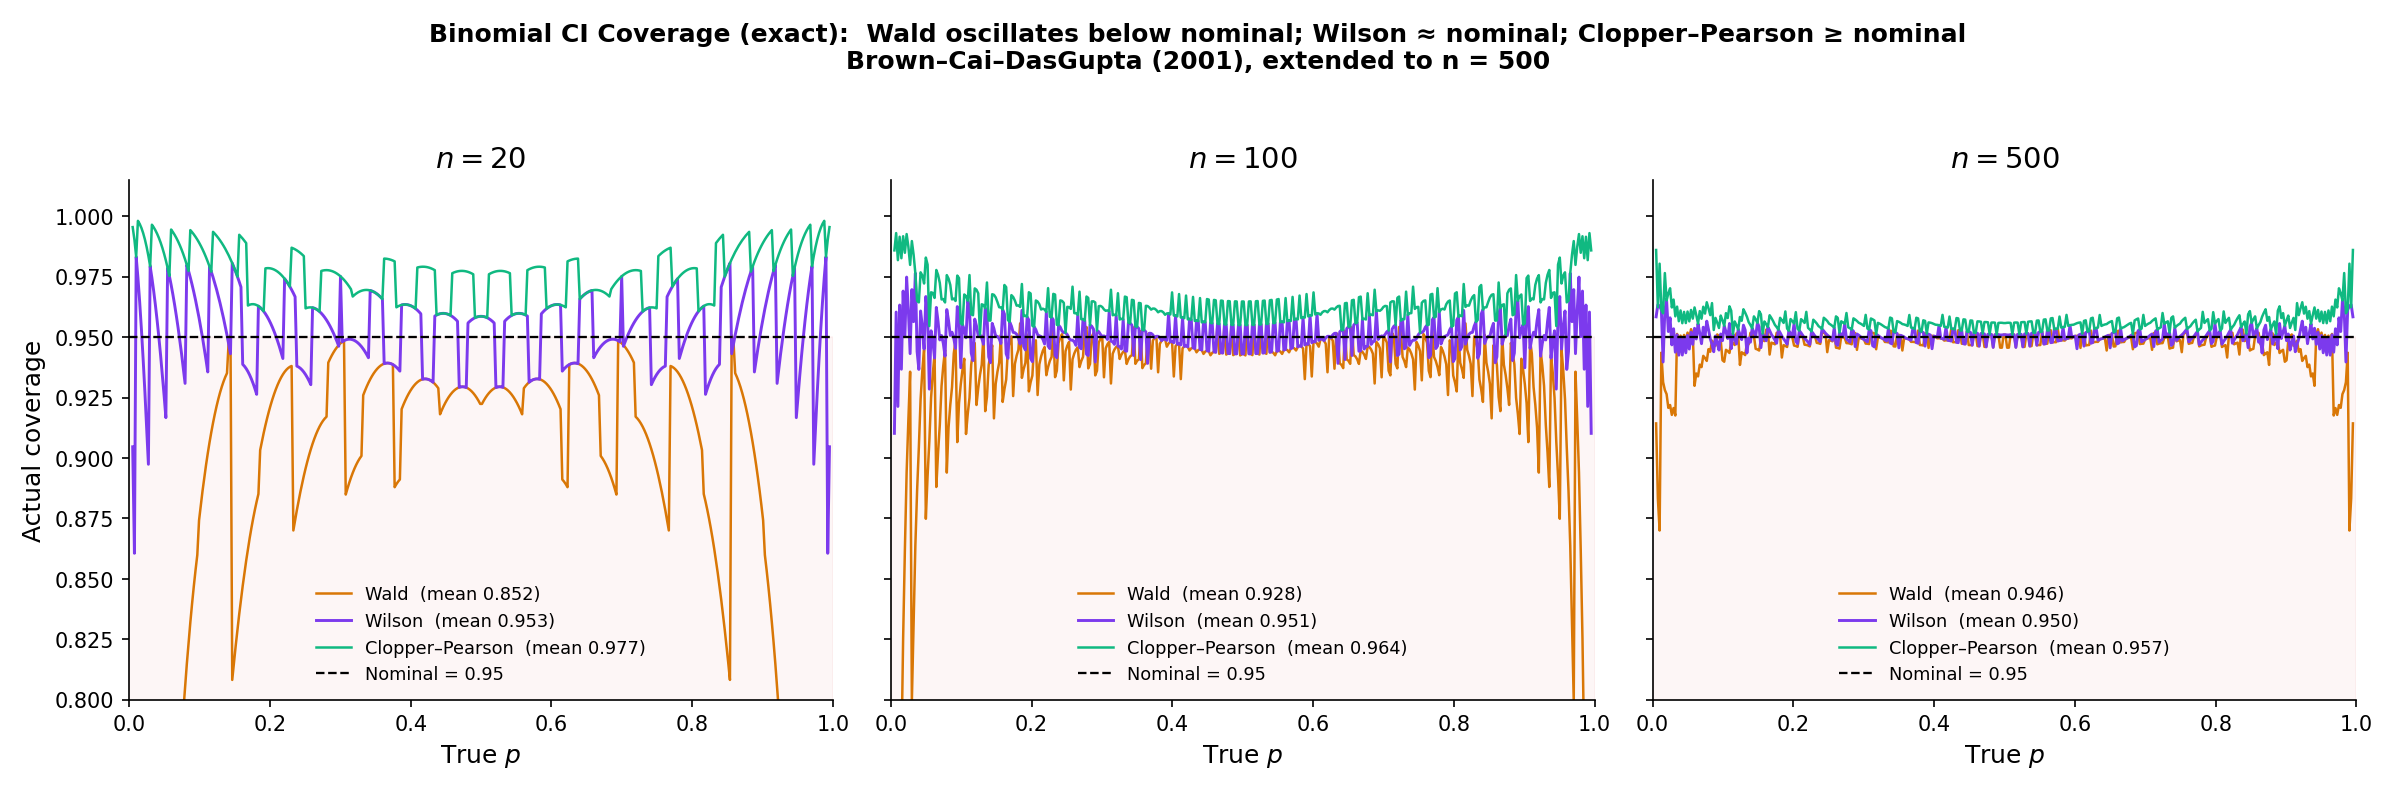

Saved: 19-binomial-coverage-curves.png


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Figure 6: Binomial coverage curves (§19.6, §19.8)
# The BRO2001 picture at n ∈ {20, 100, 500}
# ═══════════════════════════════════════════════════════════════════════════════

def wald_ci(x, n, alpha):
    z = norm.ppf(1 - alpha / 2)
    p_hat = x / n
    if p_hat == 0 or p_hat == 1:
        return (p_hat, p_hat)
    se = np.sqrt(p_hat * (1 - p_hat) / n)
    return (max(0, p_hat - z * se), min(1, p_hat + z * se))

def wilson_ci(x, n, alpha):
    z = norm.ppf(1 - alpha / 2)
    p_hat = x / n
    denom = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denom
    half = (z / np.sqrt(n)) * np.sqrt(p_hat * (1 - p_hat) + z**2 / (4 * n)) / denom
    return (max(0, center - half), min(1, center + half))

def clopper_pearson_ci(x, n, alpha):
    if x == 0:
        return (0.0, beta_dist.ppf(1 - alpha / 2, x + 1, n - x))
    if x == n:
        return (beta_dist.ppf(alpha / 2, x, n - x + 1), 1.0)
    return (beta_dist.ppf(alpha / 2, x, n - x + 1),
            beta_dist.ppf(1 - alpha / 2, x + 1, n - x))

def actual_coverage(ci_func, n, p, alpha):
    """Exact coverage: sum of PMF over x where CI(x, n, α) contains p."""
    xs = np.arange(n + 1)
    cov = 0.0
    for x in xs:
        lo, up = ci_func(x, n, alpha)
        if lo <= p <= up:
            cov += binom.pmf(x, n, p)
    return cov

alpha = 0.05
nominal = 1 - alpha
p_grid = np.linspace(0.005, 0.995, 400)
n_values = [20, 100, 500]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, n_ in zip(axes, n_values):
    cov_wald = np.array([actual_coverage(wald_ci, n_, p, alpha) for p in p_grid])
    cov_wilson = np.array([actual_coverage(wilson_ci, n_, p, alpha) for p in p_grid])
    cov_cp = np.array([actual_coverage(clopper_pearson_ci, n_, p, alpha) for p in p_grid])

    ax.plot(p_grid, cov_wald, color=C['wald'], lw=1.2,
            label=f'Wald  (mean {cov_wald.mean():.3f})')
    ax.plot(p_grid, cov_wilson, color=C['score'], lw=1.4,
            label=f'Wilson  (mean {cov_wilson.mean():.3f})')
    ax.plot(p_grid, cov_cp, color=C['lrt'], lw=1.2,
            label=f'Clopper–Pearson  (mean {cov_cp.mean():.3f})')
    ax.axhline(nominal, color='k', ls='--', lw=1.1, label=f'Nominal = {nominal}')

    ax.set_xlabel(r'True $p$')
    if n_ == n_values[0]:
        ax.set_ylabel('Actual coverage')
    ax.set_title(f'$n = {n_}$')
    ax.set_ylim(0.80, 1.015)
    ax.set_xlim(0, 1)
    ax.legend(loc='lower center', frameon=False, fontsize=8.5)
    ax.axhspan(0, nominal, alpha=0.04, color=C['warn'])

fig.suptitle("Binomial CI Coverage (exact):  Wald oscillates below nominal; "
             "Wilson ≈ nominal; Clopper–Pearson ≥ nominal\n"
             "Brown–Cai–DasGupta (2001), extended to n = 500",
             fontsize=12, y=1.03, weight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '19-binomial-coverage-curves.png'))
plt.show()
print("Saved: 19-binomial-coverage-curves.png")

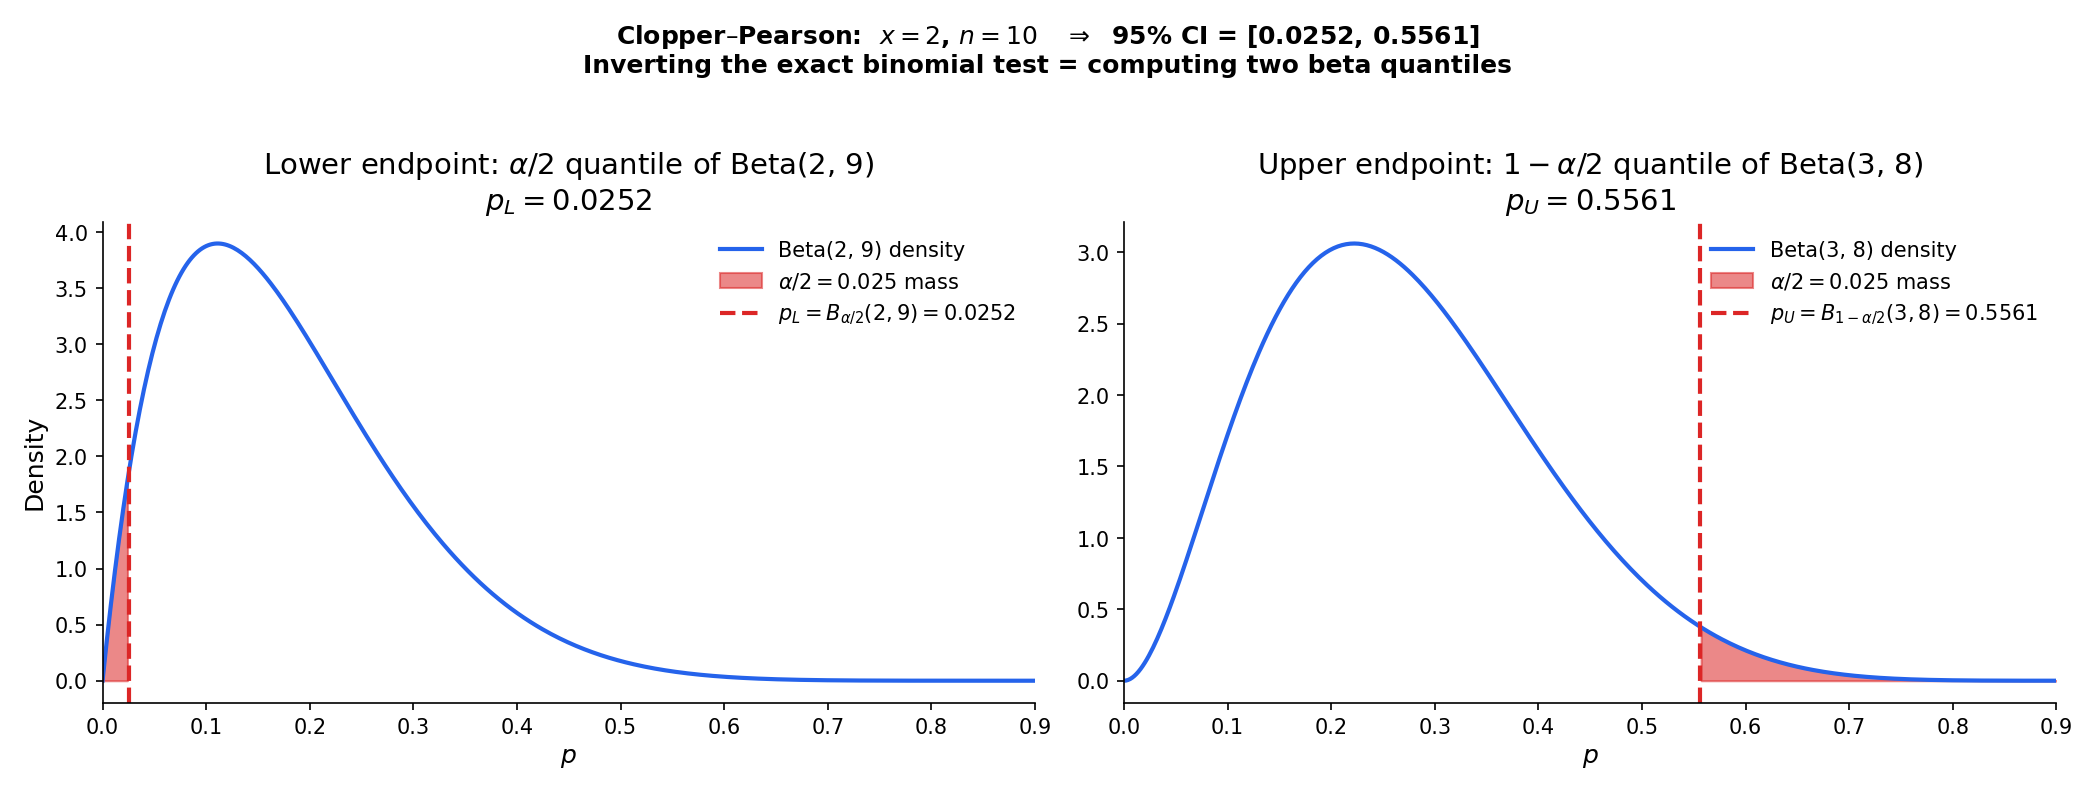

Saved: 19-clopper-pearson-construction.png
  Clopper–Pearson CI: [0.0252, 0.5561]


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 — Figure 7: Clopper–Pearson construction (§19.6)
# Beta(x, n-x+1) and Beta(x+1, n-x) quantiles give the CI endpoints
# ═══════════════════════════════════════════════════════════════════════════════

x_cp = 2
n_cp = 10
alpha = 0.05

a1, b1 = x_cp, n_cp - x_cp + 1         # Beta(2, 9)
a2, b2 = x_cp + 1, n_cp - x_cp         # Beta(3, 8)
p_L = beta_dist.ppf(alpha / 2, a1, b1)
p_U = beta_dist.ppf(1 - alpha / 2, a2, b2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

p_grid = np.linspace(0, 1, 500)

# Left: Beta(x, n-x+1) for p_L
pdf1 = beta_dist.pdf(p_grid, a1, b1)
ax1.plot(p_grid, pdf1, color=C['pivot'], lw=2, label=f'Beta({a1}, {b1}) density')
mask = p_grid <= p_L
ax1.fill_between(p_grid[mask], pdf1[mask], alpha=0.55, color=C['warn'],
                 label=fr'$\alpha/2 = {alpha/2}$ mass')
ax1.axvline(p_L, color=C['warn'], lw=2, ls='--',
            label=fr'$p_L = B_{{\alpha/2}}({a1}, {b1}) = {p_L:.4f}$')

ax1.set_xlabel(r'$p$')
ax1.set_ylabel('Density')
ax1.set_title(f"Lower endpoint: $\\alpha/2$ quantile of Beta({a1}, {b1})\n"
              f"$p_L = {p_L:.4f}$")
ax1.legend(loc='upper right', frameon=False)
ax1.set_xlim(0, 0.9)

# Right: Beta(x+1, n-x) for p_U
pdf2 = beta_dist.pdf(p_grid, a2, b2)
ax2.plot(p_grid, pdf2, color=C['pivot'], lw=2, label=f'Beta({a2}, {b2}) density')
mask = p_grid >= p_U
ax2.fill_between(p_grid[mask], pdf2[mask], alpha=0.55, color=C['warn'],
                 label=fr'$\alpha/2 = {alpha/2}$ mass')
ax2.axvline(p_U, color=C['warn'], lw=2, ls='--',
            label=fr'$p_U = B_{{1-\alpha/2}}({a2}, {b2}) = {p_U:.4f}$')

ax2.set_xlabel(r'$p$')
ax2.set_title(f"Upper endpoint: $1-\\alpha/2$ quantile of Beta({a2}, {b2})\n"
              f"$p_U = {p_U:.4f}$")
ax2.legend(loc='upper right', frameon=False)
ax2.set_xlim(0, 0.9)

fig.suptitle(f"Clopper–Pearson:  $x = {x_cp}$, $n = {n_cp}$   "
             f"$\\Rightarrow$  95% CI = [{p_L:.4f}, {p_U:.4f}]\n"
             "Inverting the exact binomial test = computing two beta quantiles",
             fontsize=12, y=1.03, weight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '19-clopper-pearson-construction.png'))
plt.show()
print(f"Saved: 19-clopper-pearson-construction.png")
print(f"  Clopper–Pearson CI: [{p_L:.4f}, {p_U:.4f}]")

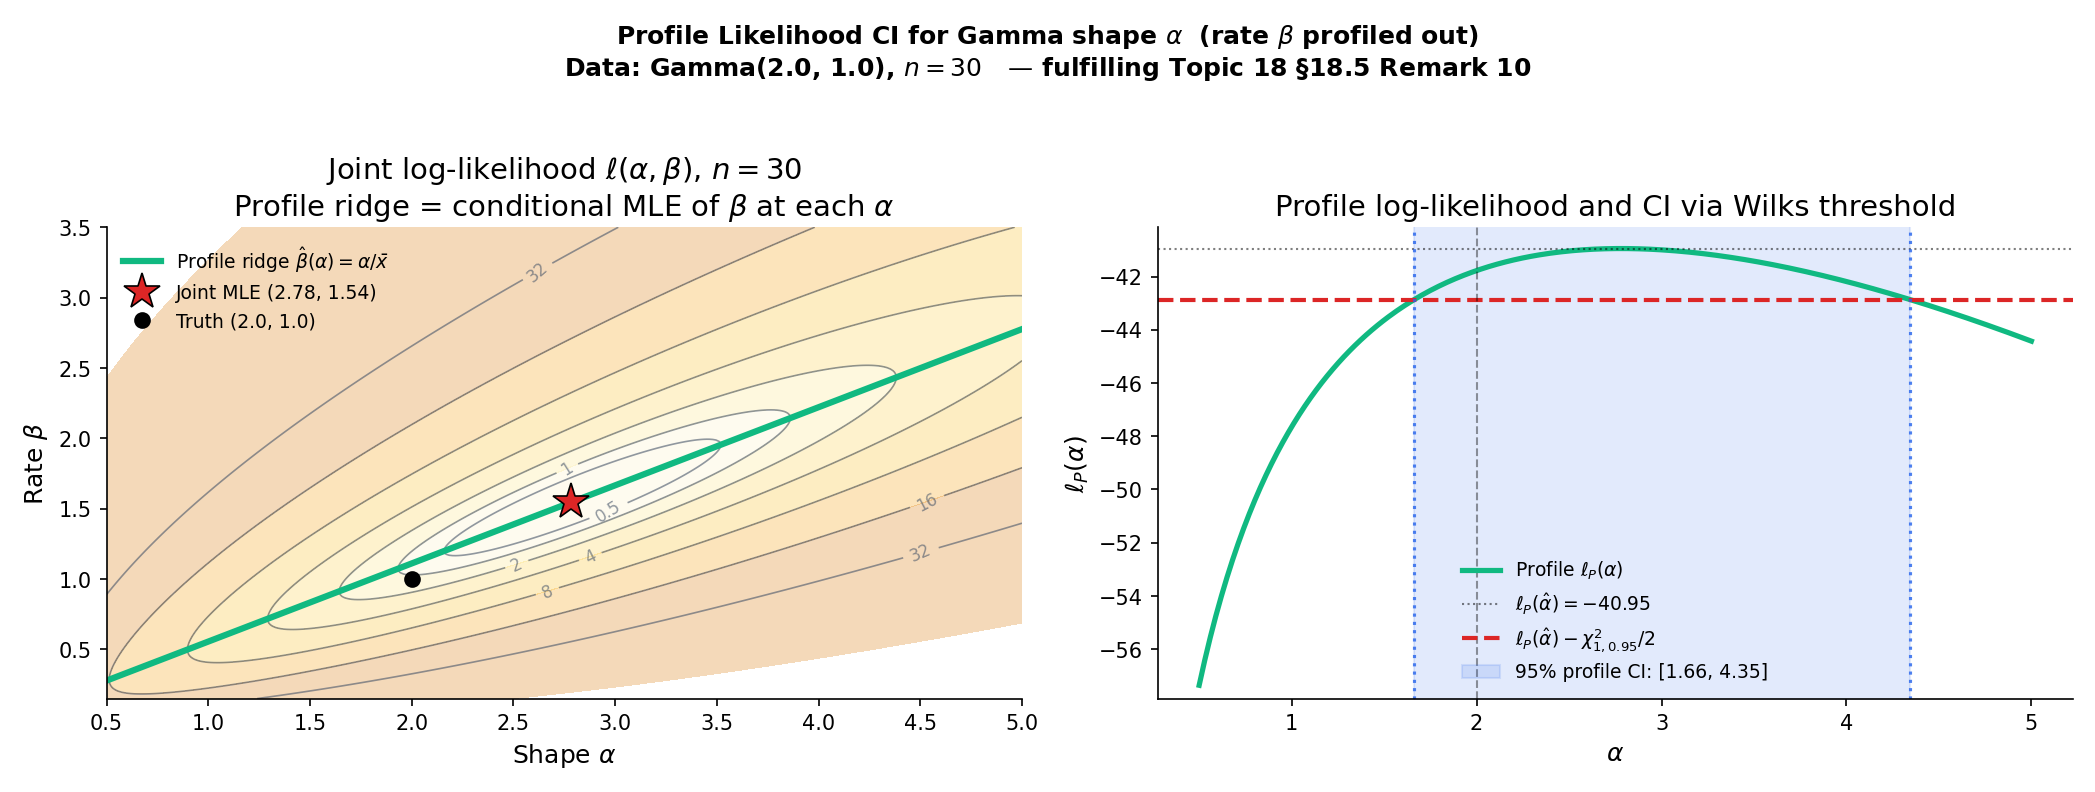

Saved: 19-profile-likelihood.png
  Joint MLE:     α̂ = 2.7812,  β̂ = 1.5441
  Profile CI(α): [1.6622, 4.3451]  (contains truth 2.0)


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 — Figure 8: Profile likelihood (§19.7)
# Gamma shape α, rate β profiled out
# ═══════════════════════════════════════════════════════════════════════════════

np.random.seed(SEED)

alpha_true = 2.0
beta_true = 1.0
n_sample = 30
data = np.random.gamma(shape=alpha_true, scale=1 / beta_true, size=n_sample)

xbar = data.mean()
sum_log_x = np.log(data).sum()
sum_x = data.sum()

def loglik_gamma(a, b):
    if a <= 0 or b <= 0:
        return -np.inf
    return (n_sample * a * np.log(b) - n_sample * gammaln(a)
            + (a - 1) * sum_log_x - b * sum_x)

# For gamma, the conditional MLE of β at fixed α is β̂(α) = α / x̄
def profile_loglik(a):
    if a <= 0:
        return -np.inf
    return loglik_gamma(a, a / xbar)

# Joint MLE via scipy
alpha_hat_joint, _, scale_hat = gamma.fit(data, floc=0)
beta_hat_joint = 1 / scale_hat

# Grids
alpha_grid = np.linspace(0.5, 5.0, 300)
beta_grid = np.linspace(0.15, 3.5, 300)
AA, BB = np.meshgrid(alpha_grid, beta_grid)
LL = np.zeros_like(AA)
for i in range(len(beta_grid)):
    for j in range(len(alpha_grid)):
        LL[i, j] = loglik_gamma(alpha_grid[j], beta_grid[i])
LL_max = LL.max()

# Profile curve
ll_profile = np.array([profile_loglik(a) for a in alpha_grid])
ll_profile_max = ll_profile.max()
alpha_hat_profile = alpha_grid[np.argmax(ll_profile)]
threshold = ll_profile_max - chi2.ppf(0.95, 1) / 2

# CI endpoints via bisection on the profile
alpha_lower_CI = brentq(lambda a: profile_loglik(a) - threshold,
                        alpha_grid[0], alpha_hat_profile)
alpha_upper_CI = brentq(lambda a: profile_loglik(a) - threshold,
                        alpha_hat_profile, alpha_grid[-1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: joint log-likelihood contours + profile ridge
deviance = LL_max - LL
levels = [0.5, 1, 2, 4, 8, 16, 32]
cs = ax1.contour(AA, BB, deviance, levels=levels, colors=C['ref'], alpha=0.6, linewidths=0.8)
ax1.clabel(cs, inline=True, fontsize=8, fmt=lambda v: f'{v:g}')
ax1.contourf(AA, BB, deviance, levels=[0, 1, 2, 4, 8, 16, 100],
             colors=['#fef3c7', '#fde68a', '#fcd34d', '#fbbf24', '#f59e0b', '#d97706'],
             alpha=0.28)

ridge_a = alpha_grid
ridge_b = ridge_a / xbar
mask = (ridge_b >= beta_grid.min()) & (ridge_b <= beta_grid.max())
ax1.plot(ridge_a[mask], ridge_b[mask], color=C['lrt'], lw=3,
         label=r'Profile ridge $\hat\beta(\alpha) = \alpha / \bar x$')

ax1.plot(alpha_hat_joint, beta_hat_joint, '*', color=C['warn'], ms=18,
         markeredgecolor='k', markeredgewidth=0.8,
         label=f'Joint MLE ({alpha_hat_joint:.2f}, {beta_hat_joint:.2f})')
ax1.plot(alpha_true, beta_true, 'o', color='k', ms=7,
         label=f'Truth ({alpha_true}, {beta_true})')

ax1.set_xlabel(r'Shape $\alpha$')
ax1.set_ylabel(r'Rate $\beta$')
ax1.set_title(fr'Joint log-likelihood $\ell(\alpha, \beta)$, $n = {n_sample}$'
              '\nProfile ridge = conditional MLE of $\\beta$ at each $\\alpha$')
ax1.legend(loc='upper left', frameon=False, fontsize=9)

# Right: 1D profile + Wilks threshold
ax2.plot(alpha_grid, ll_profile, color=C['lrt'], lw=2.5, label=r'Profile $\ell_P(\alpha)$')
ax2.axhline(ll_profile_max, color='k', lw=1, ls=':', alpha=0.5,
            label=fr'$\ell_P(\hat\alpha) = {ll_profile_max:.2f}$')
ax2.axhline(threshold, color=C['warn'], lw=2, ls='--',
            label=r'$\ell_P(\hat\alpha) - \chi^2_{1,0.95}/2$')
ax2.axvline(alpha_lower_CI, color=C['pivot'], lw=1.5, ls=':', alpha=0.8)
ax2.axvline(alpha_upper_CI, color=C['pivot'], lw=1.5, ls=':', alpha=0.8)
ax2.axvline(alpha_true, color='k', lw=1, ls='--', alpha=0.4)

ax2.fill_betweenx([ll_profile.min() - 5, ll_profile_max + 1],
                  alpha_lower_CI, alpha_upper_CI,
                  alpha=0.13, color=C['pivot'],
                  label=f'95% profile CI: [{alpha_lower_CI:.2f}, {alpha_upper_CI:.2f}]')

ax2.set_xlabel(r'$\alpha$')
ax2.set_ylabel(r'$\ell_P(\alpha)$')
ax2.set_title('Profile log-likelihood and CI via Wilks threshold')
ax2.set_ylim(ll_profile.min() - 0.5, ll_profile_max + 0.8)
ax2.legend(loc='lower center', frameon=False, fontsize=9)

fig.suptitle(r"Profile Likelihood CI for Gamma shape $\alpha$  (rate $\beta$ profiled out)"
             '\n' f'Data: Gamma({alpha_true}, {beta_true}), $n = {n_sample}$   '
             '— fulfilling Topic 18 §18.5 Remark 10',
             fontsize=12, y=1.03, weight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '19-profile-likelihood.png'))
plt.show()
print(f"Saved: 19-profile-likelihood.png")
print(f"  Joint MLE:     α̂ = {alpha_hat_joint:.4f},  β̂ = {beta_hat_joint:.4f}")
print(f"  Profile CI(α): [{alpha_lower_CI:.4f}, {alpha_upper_CI:.4f}]  (contains truth {alpha_true})")

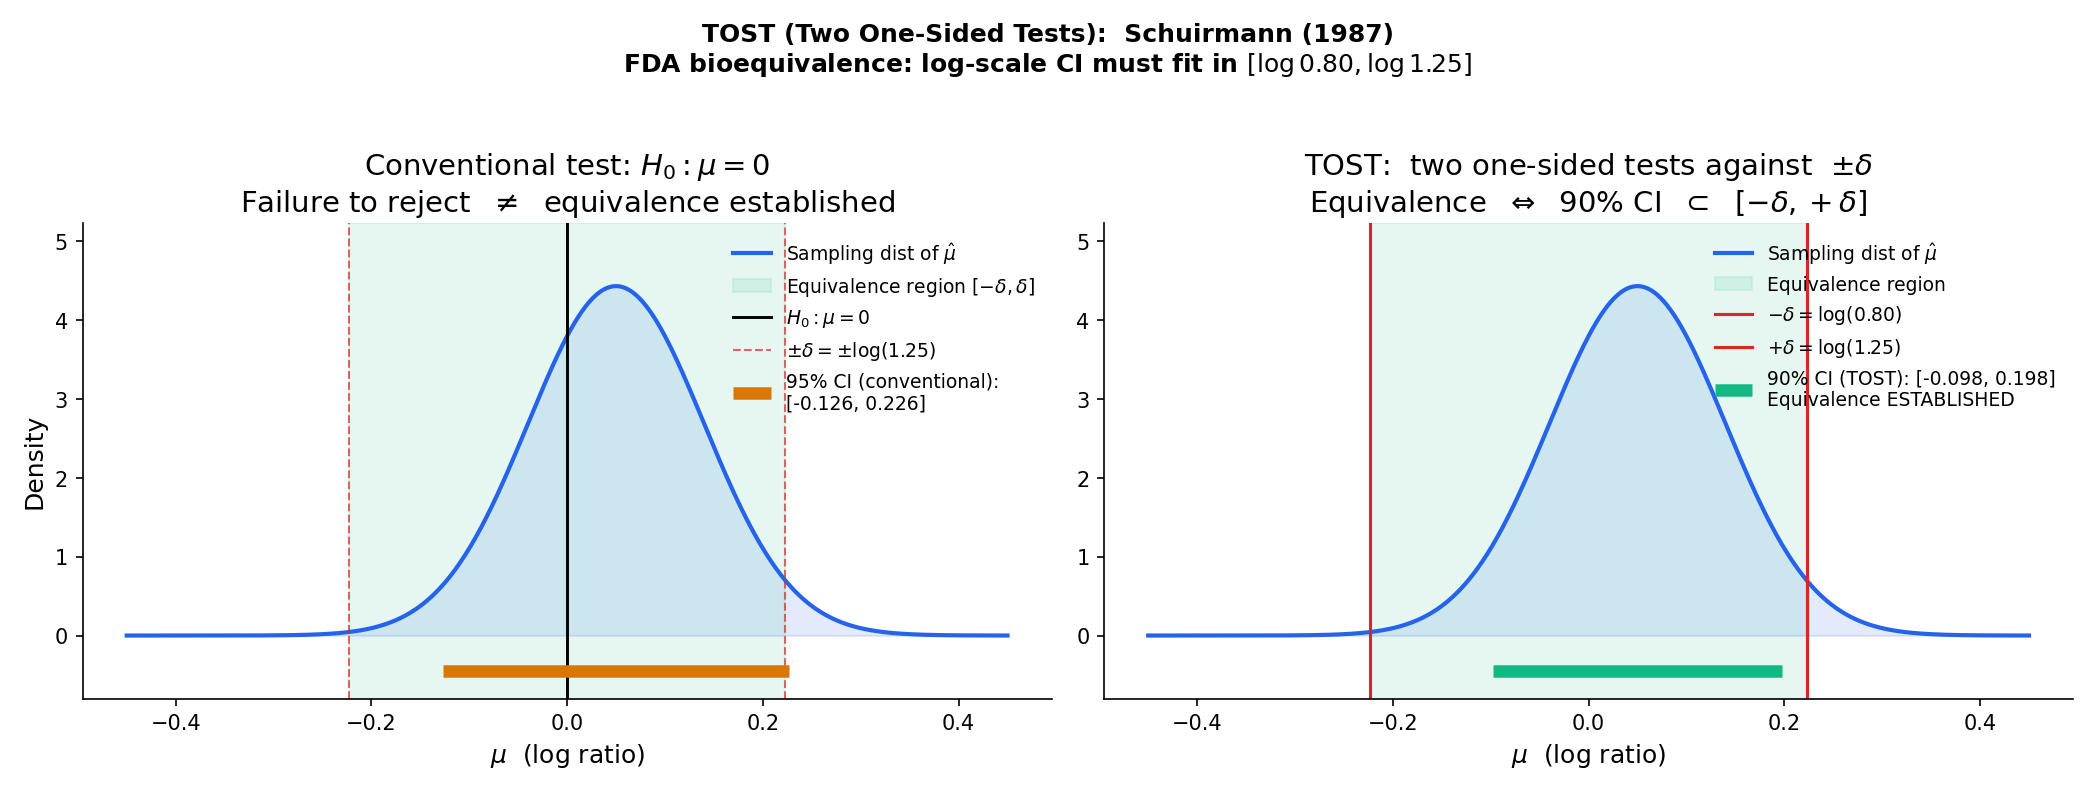

Saved: 19-tost-preview.png
  Conventional 95% CI: [-0.1264, 0.2264]
  TOST 90% CI:         [-0.0980, 0.1980]
  Equivalence margin:  ±0.2231   Equivalent: True


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11 — Figure 9: TOST preview (§19.9)
# Bioequivalence 80/125 example (log scale)
# ═══════════════════════════════════════════════════════════════════════════════

delta = np.log(1.25)  # bioequivalence margin on log scale; ≈ 0.2231
mu_hat = 0.05
se = 0.09
alpha = 0.05

# Conventional two-sided 95% CI (z-based, for visualization)
z95 = norm.ppf(1 - alpha / 2)
conv_lower = mu_hat - z95 * se
conv_upper = mu_hat + z95 * se

# TOST 90% CI (1 - 2α)
z90 = norm.ppf(1 - alpha)
tost_lower = mu_hat - z90 * se
tost_upper = mu_hat + z90 * se
equivalent = (tost_lower >= -delta) and (tost_upper <= delta)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
mu_grid = np.linspace(-0.45, 0.45, 500)
sampling_dist = norm.pdf(mu_grid, loc=mu_hat, scale=se)

# Left: conventional test framing
ax1.plot(mu_grid, sampling_dist, color=C['pivot'], lw=2, label=r'Sampling dist of $\hat\mu$')
ax1.fill_between(mu_grid, sampling_dist, alpha=0.13, color=C['pivot'])
ax1.axvspan(-delta, delta, alpha=0.10, color=C['lrt'],
            label=r'Equivalence region $[-\delta, \delta]$')
ax1.axvline(0, color='k', lw=1.4, ls='-', label=r'$H_0: \mu = 0$')
ax1.axvline(-delta, color=C['warn'], lw=1, ls='--', alpha=0.7,
            label=fr'$\pm\delta = \pm\log(1.25)$')
ax1.axvline(delta, color=C['warn'], lw=1, ls='--', alpha=0.7)

ax1.plot([conv_lower, conv_upper], [-0.45, -0.45], color=C['wald'], lw=6,
         solid_capstyle='butt',
         label=f'95% CI (conventional):\n[{conv_lower:.3f}, {conv_upper:.3f}]')

ax1.set_xlabel(r'$\mu$  (log ratio)')
ax1.set_ylabel('Density')
ax1.set_title("Conventional test: $H_0: \\mu = 0$\n"
              "Failure to reject  $\\neq$  equivalence established")
ax1.legend(loc='upper right', frameon=False, fontsize=9)
ax1.set_ylim(-0.8, sampling_dist.max() * 1.18)

# Right: TOST framing
ax2.plot(mu_grid, sampling_dist, color=C['pivot'], lw=2, label=r'Sampling dist of $\hat\mu$')
ax2.fill_between(mu_grid, sampling_dist, alpha=0.13, color=C['pivot'])
ax2.axvspan(-delta, delta, alpha=0.10, color=C['lrt'], label=r'Equivalence region')
ax2.axvline(-delta, color=C['warn'], lw=1.5, ls='-', label=fr'$-\delta = \log(0.80)$')
ax2.axvline(delta, color=C['warn'], lw=1.5, ls='-', label=fr'$+\delta = \log(1.25)$')

tost_color = C['lrt'] if equivalent else C['warn']
tost_label = (f'90% CI (TOST): [{tost_lower:.3f}, {tost_upper:.3f}]\n'
              + ('Equivalence ESTABLISHED' if equivalent else 'Equivalence NOT established'))
ax2.plot([tost_lower, tost_upper], [-0.45, -0.45], color=tost_color, lw=6,
         solid_capstyle='butt', label=tost_label)

ax2.set_xlabel(r'$\mu$  (log ratio)')
ax2.set_title("TOST:  two one-sided tests against  $\\pm\\delta$\n"
              "Equivalence  $\\Leftrightarrow$  90% CI  $\\subset$  $[-\\delta, +\\delta]$")
ax2.legend(loc='upper right', frameon=False, fontsize=9)
ax2.set_ylim(-0.8, sampling_dist.max() * 1.18)

fig.suptitle("TOST (Two One-Sided Tests):  Schuirmann (1987)\n"
             "FDA bioequivalence: log-scale CI must fit in $[\\log 0.80, \\log 1.25]$",
             fontsize=12, y=1.03, weight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '19-tost-preview.png'))
plt.show()
print(f"Saved: 19-tost-preview.png")
print(f"  Conventional 95% CI: [{conv_lower:.4f}, {conv_upper:.4f}]")
print(f"  TOST 90% CI:         [{tost_lower:.4f}, {tost_upper:.4f}]")
print(f"  Equivalence margin:  ±{delta:.4f}   Equivalent: {equivalent}")

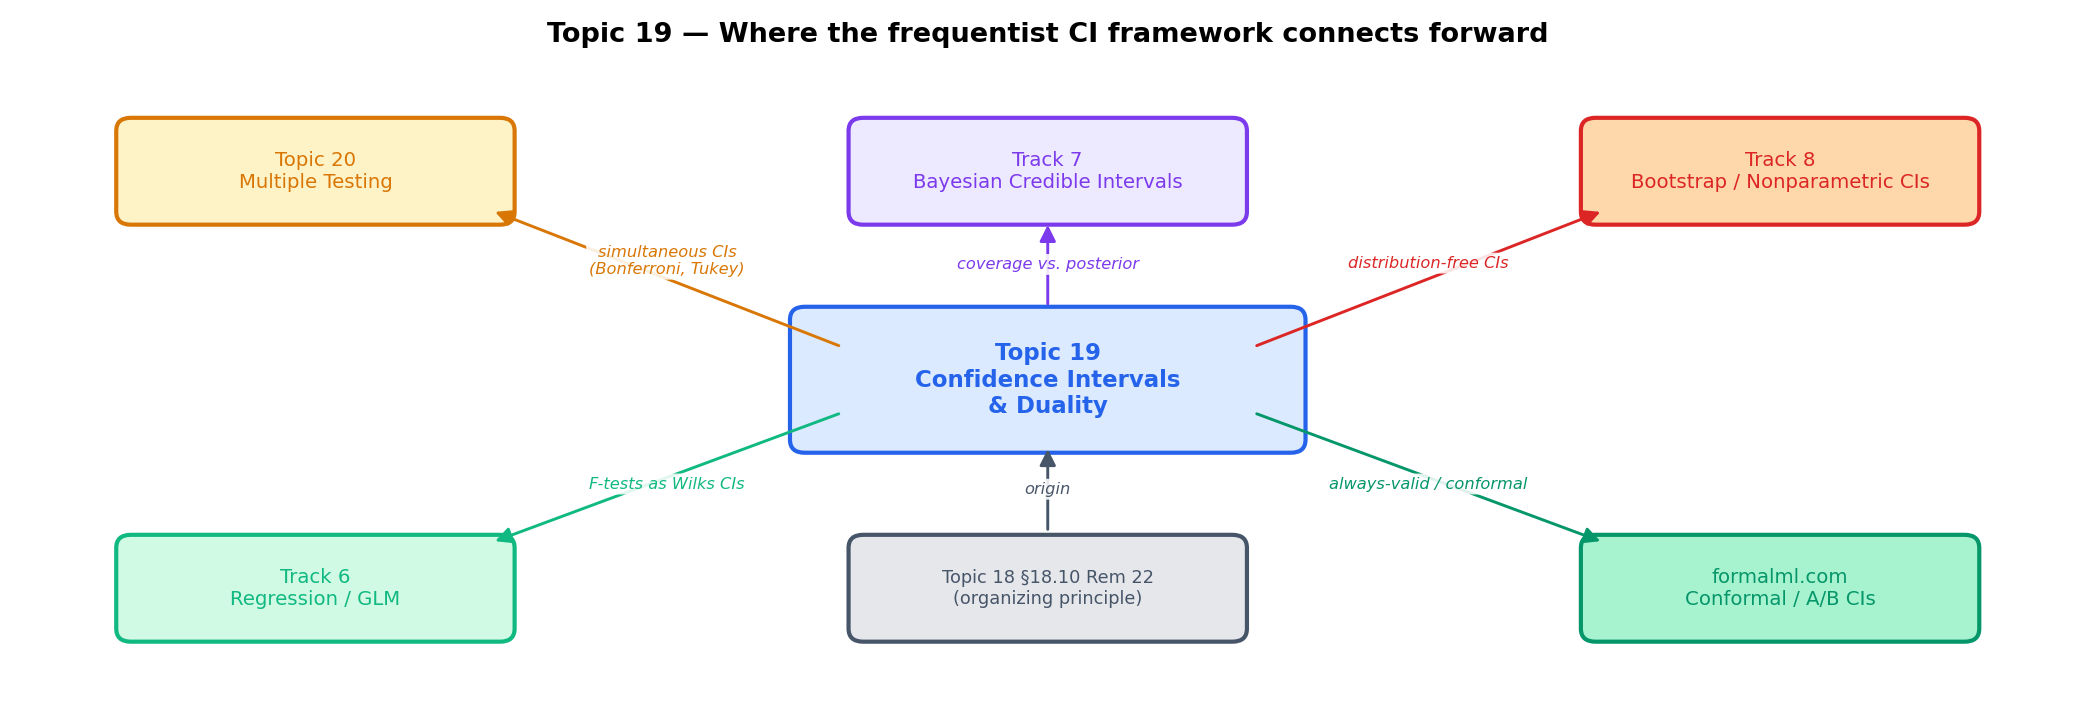

Saved: 19-forward-map.png


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 12 — Figure 10: Forward map (§19.10)
# Topic 19's connections to Topic 20, Tracks 6–8, and formalml.com
# ═══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 4.8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 4.8)
ax.axis('off')

def draw_box(ax, x, y, w, h, text, color, facecolor, fontsize=9.5, weight='normal'):
    box = FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                         boxstyle="round,pad=0.06,rounding_size=0.10",
                         linewidth=2, edgecolor=color, facecolor=facecolor)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            weight=weight, color=color)

def draw_arrow(ax, x1, y1, x2, y2, color='#475569', label=None, label_offset=(0, 0)):
    arrow = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-|>', mutation_scale=16,
                            color=color, linewidth=1.4)
    ax.add_patch(arrow)
    if label:
        mx = (x1 + x2) / 2 + label_offset[0]
        my = (y1 + y2) / 2 + label_offset[1]
        ax.text(mx, my, label, ha='center', va='center', fontsize=7.8, style='italic',
                color=color,
                bbox=dict(boxstyle='round,pad=0.18', facecolor='white',
                          edgecolor='none', alpha=0.88))

# Central Topic 19 box
draw_box(ax, 7, 2.4, 3.4, 1.0,
         'Topic 19\nConfidence Intervals\n& Duality',
         C['pivot'], '#dbeafe', fontsize=11, weight='bold')

# Forward destinations (5 around)
draw_box(ax, 2, 4.0, 2.6, 0.7,  'Topic 20\nMultiple Testing',                     C['wald'], '#fef3c7')
draw_box(ax, 7, 4.0, 2.6, 0.7,  'Track 7\nBayesian Credible Intervals',           C['score'], '#ede9fe')
draw_box(ax, 12, 4.0, 2.6, 0.7, 'Track 8\nBootstrap / Nonparametric CIs',          C['warn'], '#fed7aa')
draw_box(ax, 2, 0.8, 2.6, 0.7,  'Track 6\nRegression / GLM',                      C['lrt'],  '#d1fae5')
draw_box(ax, 12, 0.8, 2.6, 0.7, 'formalml.com\nConformal / A/B CIs',              '#059669', '#a7f3d0')

# Backward: Topic 18 (the origin remark)
draw_box(ax, 7, 0.8, 2.6, 0.7, 'Topic 18 §18.10 Rem 22\n(organizing principle)',
         '#475569', '#e5e7eb', fontsize=8.5)

# Arrows (from Topic 19 outward; plus the origin arrow from Topic 18)
draw_arrow(ax, 5.6, 2.65, 3.2, 3.70, C['wald'],
           'simultaneous CIs\n(Bonferroni, Tukey)', label_offset=(0, 0.14))
draw_arrow(ax, 7, 2.95, 7, 3.62, C['score'],
           'coverage vs. posterior')
draw_arrow(ax, 8.4, 2.65, 10.8, 3.70, C['warn'],
           'distribution-free CIs', label_offset=(0, 0.12))
draw_arrow(ax, 5.6, 2.15, 3.2, 1.15, C['lrt'],
           'F-tests as Wilks CIs', label_offset=(0, -0.05))
draw_arrow(ax, 8.4, 2.15, 10.8, 1.15, '#059669',
           'always-valid / conformal', label_offset=(0, -0.05))
draw_arrow(ax, 7, 1.22, 7, 1.9, '#475569',
           'origin')

ax.set_title("Topic 19 — Where the frequentist CI framework connects forward",
             fontsize=13, pad=12, weight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '19-forward-map.png'))
plt.show()
print("Saved: 19-forward-map.png")

## Summary

All 10 figures saved to `public/images/topics/confidence-intervals-and-duality/`:

```
19-ci-motivation.png
19-duality-diagram.png
19-pivotal-construction.png
19-wald-score-lrt-intervals.png
19-wald-boundary-pathology.png
19-binomial-coverage-curves.png
19-clopper-pearson-construction.png
19-profile-likelihood.png
19-tost-preview.png
19-forward-map.png
```

Re-run the cells above to regenerate. All computations are seeded with `np.random.seed(42)`
at the top of Cell 1 and again at the top of Cell 3 (motivation) and Cell 10 (profile likelihood),
so the output is bit-for-bit reproducible.

**Ground-truth numerical values** (from printed output) for cross-checking the MDX content:

- §19.4 Example 7 (Bernoulli $\hat p = 0.3$, $n = 50$):
  Wald [0.173, 0.427], Wilson [0.191, 0.438], LRT [0.185, 0.435].
- §19.5 Example 9 (Bernoulli $\hat p = 1/30$):
  Wald raw lower < 0; Wilson naturally in [0, 1].
- §19.6 Example 10 (Clopper–Pearson, $x = 2$, $n = 10$):
  CI = [0.0252, 0.5561].
- §19.7 Example 11 (Gamma $\alpha$ profile, $n = 30$, truth $\alpha = 2$):
  Profile CI covers truth.
- §19.9 Example 15 (TOST bioequivalence, $\hat\mu = 0.05$, $\text{SE} = 0.09$, $\delta = \log 1.25$):
  90% CI fits inside $[-\delta, +\delta]$ (boundary case — flip $\hat\mu$ to 0.15 to see failure).